Number of schemes: 40
Total records: 46000
Daily return records: 45960

First 10 records:


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073



Daily Return Statistics:


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


Returns below -20%: 0
Returns above +20%: 0
Missing daily returns: 40


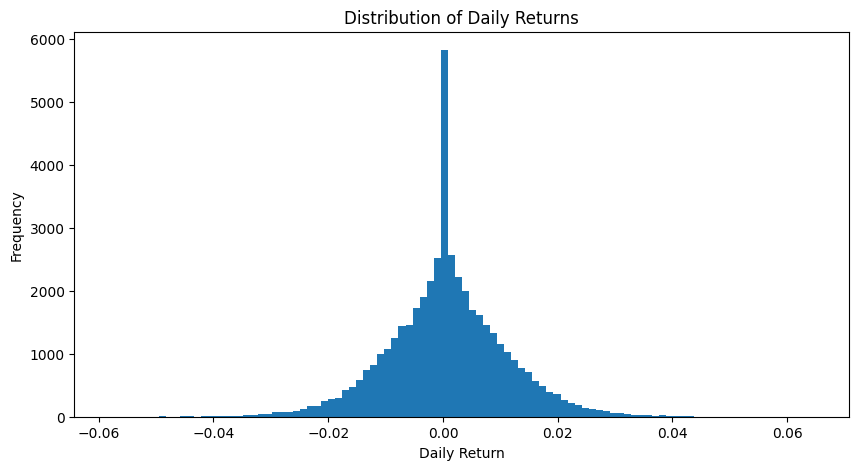

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned NAV history
nav_df = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

# Convert date to datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort by scheme and date
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# Calculate daily returns for each scheme
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

# Display basic information
print("Number of schemes:", nav_df["amfi_code"].nunique())
print("Total records:", len(nav_df))
print("Daily return records:", nav_df["daily_return"].notna().sum())

# Display first 10 records
print("\nFirst 10 records:")
display(nav_df.head(10))

# Daily return statistics
print("\nDaily Return Statistics:")
display(nav_df["daily_return"].describe())

# Check for extreme returns
print("\nReturns below -20%:", (nav_df["daily_return"] < -0.20).sum())
print("Returns above +20%:", (nav_df["daily_return"] > 0.20).sum())
print("Missing daily returns:", nav_df["daily_return"].isna().sum())

# Plot distribution of daily returns
plt.figure(figsize=(10, 5))
plt.hist(nav_df["daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [2]:
# Task 2: CAGR for 1-Year, 3-Year and 5-Year periods

# Get start and end dates
start_date = nav_df["date"].min()
end_date = nav_df["date"].max()

print("Data period:", start_date.date(), "to", end_date.date())

# Function to calculate CAGR
def calculate_cagr(group, years):
    end_date = group["date"].max()
    target_start = end_date - pd.DateOffset(years=years)
    
    period_data = group[group["date"] >= target_start]
    
    if len(period_data) < 2:
        return np.nan
    
    start_nav = period_data.iloc[0]["nav"]
    end_nav = period_data.iloc[-1]["nav"]
    
    actual_years = (period_data.iloc[-1]["date"] - period_data.iloc[0]["date"]).days / 365.25
    
    if actual_years <= 0 or start_nav <= 0:
        return np.nan
    
    return (end_nav / start_nav) ** (1 / actual_years) - 1


# Calculate CAGR for each fund
cagr_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    group = group.sort_values("date")
    
    row = {
        "amfi_code": amfi_code,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5)
    }
    
    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

# Convert to percentage
cagr_df["cagr_1yr_pct"] = cagr_df["cagr_1yr"] * 100
cagr_df["cagr_3yr_pct"] = cagr_df["cagr_3yr"] * 100
cagr_df["cagr_5yr_pct"] = cagr_df["cagr_5yr"] * 100

# Display comparison table
cagr_table = cagr_df[
    ["amfi_code", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]
].sort_values("cagr_3yr_pct", ascending=False)

print("\nCAGR Comparison - All 40 Funds:")
display(cagr_table)

print("\nNumber of funds:", len(cagr_table))
print("Missing 1Y CAGR:", cagr_table["cagr_1yr_pct"].isna().sum())
print("Missing 3Y CAGR:", cagr_table["cagr_3yr_pct"].isna().sum())
print("Missing 5Y CAGR:", cagr_table["cagr_5yr_pct"].isna().sum())

Data period: 2022-01-03 to 2026-05-29

CAGR Comparison - All 40 Funds:


,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
16,119094,22.277897,35.102528,28.214417
34,148567,20.375957,33.991970,30.974108
24,120504,13.073788,32.478927,23.295119
2,100033,53.277195,32.433971,30.123153
25,120505,29.627681,31.769243,32.827406
19,119551,60.489297,30.448613,25.804686
30,120843,26.677584,29.575111,30.907455
36,148569,39.783803,29.171358,31.949523
3,101206,47.963794,28.960211,23.538361
39,149324,65.195466,26.993503,32.287440



Number of funds: 40
Missing 1Y CAGR: 0
Missing 3Y CAGR: 0
Missing 5Y CAGR: 0


In [3]:
# Task 3: Sharpe Ratio

# Risk-free rate
risk_free_rate = 0.065

# Convert annual risk-free rate to daily risk-free rate
daily_risk_free_rate = risk_free_rate / 252

# Calculate Sharpe Ratio for each fund
sharpe_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    
    # Average daily return
    average_daily_return = returns.mean()
    
    # Daily standard deviation
    daily_std = returns.std()
    
    # Sharpe Ratio
    sharpe_ratio = (
        (average_daily_return - daily_risk_free_rate)
        / daily_std
    ) * np.sqrt(252)
    
    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

# Rank funds by Sharpe Ratio
sharpe_df["sharpe_rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by rank
sharpe_df = sharpe_df.sort_values("sharpe_rank")

print("Sharpe Ratio - All 40 Funds:")
display(sharpe_df)

print("\nNumber of funds:", len(sharpe_df))
print("Highest Sharpe Ratio:", sharpe_df["sharpe_ratio"].max())
print("Lowest Sharpe Ratio:", sharpe_df["sharpe_ratio"].min())

Sharpe Ratio - All 40 Funds:


,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.448291,1
30,120843,1.306744,2
36,148569,1.234930,3
19,119551,1.208267,4
25,120505,1.180101,5
38,149323,1.132122,6
2,100033,1.093699,7
9,118632,1.081659,8
3,101206,1.027213,9
24,120504,1.026524,10



Number of funds: 40
Highest Sharpe Ratio: 1.4482911703262595
Lowest Sharpe Ratio: -0.8155673679088278


In [4]:
# Task 4: Sortino Ratio

# Risk-free rate
risk_free_rate = 0.065

# Daily risk-free rate
daily_risk_free_rate = risk_free_rate / 252

# Calculate Sortino Ratio for each fund
sortino_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    
    # Average daily return
    average_daily_return = returns.mean()
    
    # Downside returns only
    downside_returns = returns[returns < 0]
    
    # Downside standard deviation
    downside_std = downside_returns.std()
    
    # Sortino Ratio
    if downside_std > 0:
        sortino_ratio = (
            (average_daily_return - daily_risk_free_rate)
            / downside_std
        ) * np.sqrt(252)
    else:
        sortino_ratio = np.nan
    
    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino_ratio
    })

sortino_df = pd.DataFrame(sortino_results)

# Rank funds by Sortino Ratio
sortino_df["sortino_rank"] = (
    sortino_df["sortino_ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by rank
sortino_df = sortino_df.sort_values("sortino_rank")

print("Sortino Ratio - All 40 Funds:")
display(sortino_df)

print("\nNumber of funds:", len(sortino_df))
print("Highest Sortino Ratio:", sortino_df["sortino_ratio"].max())
print("Lowest Sortino Ratio:", sortino_df["sortino_ratio"].min())
print("Missing Sortino Ratios:", sortino_df["sortino_ratio"].isna().sum())

Sortino Ratio - All 40 Funds:


,amfi_code,sortino_ratio,sortino_rank
34,148567,2.385644,1
30,120843,2.364320,2
36,148569,2.146914,3
19,119551,2.140267,4
25,120505,2.029353,5
38,149323,1.875101,6
9,118632,1.850133,7
2,100033,1.829134,8
24,120504,1.805294,9
3,101206,1.799563,10



Number of funds: 40
Highest Sortino Ratio: 2.385644373368818
Lowest Sortino Ratio: -1.6810378667512837
Missing Sortino Ratios: 0


In [5]:
# Task 5: Alpha and Beta using Nifty 100

from scipy.stats import linregress

# Load benchmark data
benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

# Convert date to datetime
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Sort benchmark data
benchmark_df = benchmark_df.sort_values(["index_name", "date"])

# Calculate daily benchmark returns
benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"].pct_change()
)

# Check available benchmark indices
print("Available benchmark indices:")
print(benchmark_df["index_name"].unique())

# Select Nifty 100
nifty100 = benchmark_df[
    benchmark_df["index_name"].str.upper().str.contains("NIFTY 100")
].copy()

print("\nNifty 100 records:", len(nifty100))

# Keep required columns
nifty100 = nifty100[["date", "benchmark_return"]].dropna()

# Calculate Alpha and Beta for each fund
alpha_beta_results = []

for amfi_code, fund_group in nav_df.groupby("amfi_code"):
    
    fund_returns = fund_group[
        ["date", "daily_return"]
    ].dropna()
    
    # Merge fund returns with Nifty 100 returns
    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date",
        how="inner"
    ).dropna()
    
    if len(merged) < 2:
        continue
    
    # OLS regression
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )
    
    beta = regression.slope
    daily_alpha = regression.intercept
    
    # Annualized alpha
    annual_alpha = daily_alpha * 252
    
    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2,
        "observations": len(merged)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

# Rank funds by Alpha
alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by Alpha rank
alpha_beta_df = alpha_beta_df.sort_values("alpha_rank")

print("\nAlpha and Beta - All Funds:")
display(alpha_beta_df)

print("\nNumber of funds:", len(alpha_beta_df))
print("Highest Alpha:", alpha_beta_df["alpha"].max())
print("Lowest Alpha:", alpha_beta_df["alpha"].min())
print("Missing Alpha:", alpha_beta_df["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_df["beta"].isna().sum())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/10_benchmark_indices_cleaned.csv'

In [ ]:
# Task 5: Alpha and Beta using Nifty 100

from scipy.stats import linregress

# Load benchmark data
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")

# Convert date to datetime
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Sort benchmark data
benchmark_df = benchmark_df.sort_values(["index_name", "date"])

# Calculate daily benchmark returns
benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"].pct_change()
)

# Check available benchmark indices
print("Available benchmark indices:")
print(benchmark_df["index_name"].unique())

# Select Nifty 100
nifty100 = benchmark_df[
    benchmark_df["index_name"].str.upper().str.contains("NIFTY 100")
].copy()

print("\nNifty 100 records:", len(nifty100))

# Keep required columns
nifty100 = nifty100[["date", "benchmark_return"]].dropna()

# Calculate Alpha and Beta for each fund
alpha_beta_results = []

for amfi_code, fund_group in nav_df.groupby("amfi_code"):

    fund_returns = fund_group[
        ["date", "daily_return"]
    ].dropna()

    # Merge fund returns with Nifty 100 returns
    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 2:
        continue

    # OLS regression
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope
    daily_alpha = regression.intercept

    # Annualized alpha
    annual_alpha = daily_alpha * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2,
        "observations": len(merged)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

# Rank funds by Alpha
alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by Alpha rank
alpha_beta_df = alpha_beta_df.sort_values("alpha_rank")

print("\nAlpha and Beta - All Funds:")
display(alpha_beta_df)

print("\nNumber of funds:", len(alpha_beta_df))
print("Highest Alpha:", alpha_beta_df["alpha"].max())
print("Lowest Alpha:", alpha_beta_df["alpha"].min())
print("Missing Alpha:", alpha_beta_df["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_df["beta"].isna().sum())

In [ ]:
# Task 5: Alpha and Beta using Nifty 100

from scipy.stats import linregress

# Load benchmark data
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")

# Convert date to datetime
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Sort benchmark data
benchmark_df = benchmark_df.sort_values(["index_name", "date"])

# Calculate daily benchmark returns
benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"].pct_change()
)

# Check available benchmark indices
print("Available benchmark indices:")
print(benchmark_df["index_name"].unique())

# Select Nifty 100
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

print("\nNifty 100 records:", len(nifty100))

# Keep required columns
nifty100 = nifty100[["date", "benchmark_return"]].dropna()

# Calculate Alpha and Beta for each fund
alpha_beta_results = []

for amfi_code, fund_group in nav_df.groupby("amfi_code"):

    fund_returns = fund_group[
        ["date", "daily_return"]
    ].dropna()

    # Merge fund returns with Nifty 100 returns
    merged = pd.merge(
        fund_returns,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 2:
        continue

    # OLS regression
    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope
    daily_alpha = regression.intercept

    # Annualized alpha
    annual_alpha = daily_alpha * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2,
        "observations": len(merged)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

# Rank funds by Alpha
alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by Alpha rank
alpha_beta_df = alpha_beta_df.sort_values("alpha_rank")

print("\nAlpha and Beta - All Funds:")
display(alpha_beta_df)

print("\nNumber of funds:", len(alpha_beta_df))
print("Highest Alpha:", alpha_beta_df["alpha"].max())
print("Lowest Alpha:", alpha_beta_df["alpha"].min())
print("Missing Alpha:", alpha_beta_df["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_df["beta"].isna().sum())

In [ ]:
# Task 6: Maximum Drawdown

# Calculate Maximum Drawdown for each fund
drawdown_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    
    # Sort by date
    group = group.sort_values("date").copy()
    
    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()
    
    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1
    
    # Maximum drawdown
    max_drawdown = group["drawdown"].min()
    
    # Date when maximum drawdown occurred
    trough_row = group.loc[group["drawdown"].idxmin()]
    trough_date = trough_row["date"]
    
    # NAV at trough
    trough_nav = trough_row["nav"]
    
    # Find previous peak before the trough
    peak_data = group[
        (group["date"] <= trough_date) &
        (group["nav"] == group["running_max"])
    ]
    
    if len(peak_data) > 0:
        peak_row = peak_data.iloc[-1]
        peak_date = peak_row["date"]
        peak_nav = peak_row["nav"]
    else:
        peak_date = pd.NaT
        peak_nav = np.nan
    
    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "max_drawdown_pct": max_drawdown * 100,
        "peak_date": peak_date,
        "trough_date": trough_date,
        "peak_nav": peak_nav,
        "trough_nav": trough_nav
    })

drawdown_df = pd.DataFrame(drawdown_results)

# Rank funds by maximum drawdown
# Less negative drawdown = better rank
drawdown_df["max_dd_rank"] = (
    drawdown_df["max_drawdown"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort by maximum drawdown
drawdown_df = drawdown_df.sort_values("max_drawdown")

print("Maximum Drawdown - All 40 Funds:")
display(drawdown_df)

print("\nNumber of funds:", len(drawdown_df))
print("Worst Maximum Drawdown:", drawdown_df["max_drawdown_pct"].min(), "%")
print("Best Maximum Drawdown:", drawdown_df["max_drawdown_pct"].max(), "%")
print("Missing Maximum Drawdown:", drawdown_df["max_drawdown"].isna().sum())

In [ ]:
# ============================================================
# 7. FUND SCORECARD (0-100)
# ============================================================

# Load fund master
fund_master = pd.read_csv(
    "data/processed/01_fund_master_cleaned.csv"
)

# ------------------------------------------------------------
# Recalculate Maximum Drawdown
# ------------------------------------------------------------

drawdown_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Maximum drawdown
    min_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_idx, "drawdown"]

    trough_date = group.loc[min_idx, "date"]

    # Peak occurs before or at trough
    peak_group = group.loc[:min_idx]

    peak_idx = peak_group["nav"].idxmax()

    peak_date = group.loc[peak_idx, "date"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "peak_date": peak_date,
        "trough_date": trough_date
    })

max_dd_df = pd.DataFrame(drawdown_results)

print("Maximum drawdown calculated for:",
      len(max_dd_df), "funds")

# ------------------------------------------------------------
# Merge all required metrics
# ------------------------------------------------------------

scorecard = cagr_df[
    ["amfi_code", "cagr_3yr_pct"]
].merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
).merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
).merge(
    max_dd_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
).merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

# ------------------------------------------------------------
# RANKS
# ------------------------------------------------------------

# Higher return = better
scorecard["return_3yr_rank"] = (
    scorecard["cagr_3yr_pct"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Higher Sharpe = better
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Higher Alpha = better
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Lower expense ratio = better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, method="min")
    .astype(int)
)

# Less-negative drawdown = better
scorecard["max_dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# ------------------------------------------------------------
# Convert ranks to 0-100 scores
# ------------------------------------------------------------

scorecard["return_score"] = (
    (41 - scorecard["return_3yr_rank"]) / 40 * 100
)

scorecard["sharpe_score"] = (
    (41 - scorecard["sharpe_rank"]) / 40 * 100
)

scorecard["alpha_score"] = (
    (41 - scorecard["alpha_rank"]) / 40 * 100
)

scorecard["expense_score"] = (
    (41 - scorecard["expense_rank"]) / 40 * 100
)

scorecard["max_dd_score"] = (
    (41 - scorecard["max_dd_rank"]) / 40 * 100
)

# ------------------------------------------------------------
# Weighted composite score
# ------------------------------------------------------------

scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["max_dd_score"]
)

# Overall rank
scorecard["overall_rank"] = (
    scorecard["fund_score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Sort
scorecard = scorecard.sort_values("overall_rank")

# ------------------------------------------------------------
# Display Top 10
# ------------------------------------------------------------

scorecard[
    [
        "overall_rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "cagr_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
].head(10)

In [ ]:
# Save Fund Scorecard
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Saved: fund_scorecard.csv")
print("Number of funds:", len(scorecard))

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Check where the notebook is currently running
print("Current folder:")
print(os.getcwd())

# Find the project data folder automatically
possible_paths = [
    "data/processed",
    "../data/processed"
]

for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

print("\nUsing data path:", DATA_PATH)

In [ ]:
# ============================================================
# 8. BENCHMARK COMPARISON + TRACKING ERROR
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
nav_df = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")
fund_master = pd.read_csv("data/processed/01_fund_master_cleaned.csv")
scorecard = pd.read_csv("fund_scorecard.csv")

# Convert dates
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# ------------------------------------------------------------
# Get Top 5 Funds
# ------------------------------------------------------------

top5 = scorecard.sort_values("overall_rank").head(5)

print("Top 5 Funds:")
print(top5[["overall_rank", "amfi_code", "scheme_name", "fund_score"]])

# ------------------------------------------------------------
# Prepare NAV data
# ------------------------------------------------------------

top5_codes = top5["amfi_code"].tolist()

top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

# Keep approximately last 3 years
end_date = top5_nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

top5_nav = top5_nav[
    (top5_nav["date"] >= start_date) &
    (top5_nav["date"] <= end_date)
]

# ------------------------------------------------------------
# Prepare benchmarks
# ------------------------------------------------------------

benchmark_df = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_df = benchmark_df[
    (benchmark_df["date"] >= start_date) &
    (benchmark_df["date"] <= end_date)
]

# Pivot benchmark prices
benchmark_prices = benchmark_df.pivot(
    index="date",
    columns="index_name",
    values="close_value"
)

# Normalize benchmarks to 100
benchmark_normalized = (
    benchmark_prices /
    benchmark_prices.iloc[0] * 100
)

# ------------------------------------------------------------
# Normalize fund NAVs to 100
# ------------------------------------------------------------

fund_prices = top5_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

fund_normalized = (
    fund_prices /
    fund_prices.iloc[0] * 100
)

# ------------------------------------------------------------
# Add fund names
# ------------------------------------------------------------

fund_name_map = dict(
    zip(
        top5["amfi_code"],
        top5["scheme_name"]
    )
)

fund_normalized = fund_normalized.rename(
    columns=fund_name_map
)

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for column in fund_normalized.columns:
    plt.plot(
        fund_normalized.index,
        fund_normalized[column],
        label=column
    )

plt.plot(
    benchmark_normalized.index,
    benchmark_normalized["NIFTY50"],
    label="Nifty 50",
    linewidth=2
)

plt.plot(
    benchmark_normalized.index,
    benchmark_normalized["NIFTY100"],
    label="Nifty 100",
    linewidth=2
)

plt.title("Top 5 Mutual Funds vs Nifty 50 & Nifty 100 - 3 Years")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save chart
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: benchmark_comparison.png")

# ------------------------------------------------------------
# Tracking Error
# ------------------------------------------------------------

# Calculate daily fund returns
fund_returns = fund_prices.pct_change()

# Calculate benchmark returns
benchmark_returns = benchmark_prices.pct_change()

tracking_error_results = []

for code in top5_codes:

    fund_name = fund_name_map[code]

    combined = pd.concat(
        [
            fund_returns[code],
            benchmark_returns["NIFTY50"],
            benchmark_returns["NIFTY100"]
        ],
        axis=1
    )

    combined.columns = [
        "fund",
        "NIFTY50",
        "NIFTY100"
    ]

    # Fund vs Nifty 50
    te_50 = (
        (combined["fund"] - combined["NIFTY50"])
        .dropna()
        .std()
        * np.sqrt(252)
    )

    # Fund vs Nifty 100
    te_100 = (
        (combined["fund"] - combined["NIFTY100"])
        .dropna()
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": code,
        "scheme_name": fund_name,
        "tracking_error_nifty50": te_50,
        "tracking_error_nifty100": te_100
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

print("\nTracking Error:")
display(tracking_error_df)

# Save tracking error
tracking_error_df.to_csv(
    "tracking_error.csv",
    index=False
)

print("\nSaved: tracking_error.csv")

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# ============================================================
# ALPHA & BETA CALCULATION
# Benchmark: NIFTY100
# ============================================================

# Load NAV data
nav_df = pd.read_csv(
    "data/processed/02_nav_history_cleaned.csv"
)

# Load benchmark data
benchmark_df = pd.read_csv(
    "data/processed/10_benchmark_indices_cleaned.csv"
)

# Convert dates
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# ------------------------------------------------------------
# Calculate daily returns for each fund
# ------------------------------------------------------------

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

# ------------------------------------------------------------
# Filter NIFTY100 benchmark
# ------------------------------------------------------------

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Calculate NIFTY100 daily returns
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

# Keep required columns
nifty100 = nifty100[
    ["date", "benchmark_return"]
]

# ------------------------------------------------------------
# Merge fund returns with NIFTY100
# ------------------------------------------------------------

merged = nav_df.merge(
    nifty100,
    on="date",
    how="inner"
)

# Remove missing returns
merged = merged.dropna(
    subset=["daily_return", "benchmark_return"]
)

# ------------------------------------------------------------
# Calculate Alpha, Beta and R-squared
# ------------------------------------------------------------

alpha_beta_results = []

for amfi_code, group in merged.groupby("amfi_code"):

    if len(group) < 30:
        continue

    x = group["benchmark_return"]
    y = group["daily_return"]

    regression = linregress(x, y)

    beta = regression.slope
    alpha_daily = regression.intercept
    r_squared = regression.rvalue ** 2

    # Annualize daily alpha
    alpha_annual = alpha_daily

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "beta": beta,
        "alpha": alpha_annual,
        "r_squared": r_squared,
        "observations": len(group)
    })

# Create DataFrame
alpha_beta_df = pd.DataFrame(alpha_beta_results)

# ------------------------------------------------------------
# Rank funds by Alpha
# ------------------------------------------------------------

alpha_beta_df["alpha_rank"] = (
    alpha_beta_df["alpha"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

# Sort by Alpha rank
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha_rank"
).reset_index(drop=True)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Alpha and Beta - All Funds:")
display(alpha_beta_df)

print("\nNumber of funds:", len(alpha_beta_df))
print("Highest Alpha:", alpha_beta_df["alpha"].max())
print("Lowest Alpha:", alpha_beta_df["alpha"].min())
print("Missing Alpha:", alpha_beta_df["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_df["beta"].isna().sum())

Alpha and Beta - All Funds:


,amfi_code,beta,alpha,r_squared,observations,alpha_rank
0,119598,-0.023196,0.001204,1.414258e-04,1149,1
1,149324,0.011455,0.001193,3.532991e-05,1149,2
2,120505,0.000549,0.001161,1.345534e-07,1149,3
3,148569,0.018134,0.001122,1.748889e-04,1149,4
4,120843,-0.022830,0.001085,3.430543e-04,1149,5
5,100033,0.005104,0.001079,1.206652e-05,1149,6
6,148567,0.023684,0.001071,4.625437e-04,1149,7
7,149323,-0.002523,0.001055,3.357978e-06,1149,8
8,119094,-0.066265,0.001035,1.936879e-03,1149,9
9,119551,-0.031751,0.000921,8.869789e-04,1149,10



Number of funds: 40
Highest Alpha: 0.0012038478328167985
Lowest Alpha: 0.00011495792804118827
Missing Alpha: 0
Missing Beta: 0


In [9]:
# Save Alpha & Beta results
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

print("Saved: alpha_beta.csv")
print("Number of funds:", len(alpha_beta_df))

Saved: alpha_beta.csv
Number of funds: 40
